# HyDMIS — FakeNewsNet EDA
## News Disinformation Domain

**Dataset:** FakeNewsNet — Shu et al. (2020), Big Data  
**Records:** 23,196  
**Labels:** Binary (1=Disinformation, 0=Credible)  
**Domain:** News (Political + Celebrity), English  

**Two platforms:**
- PolitiFact: political fact-checking (4.6% of records, 40.9% dis rate)
- GossipCop: celebrity news (95.4% of records, 24.0% dis rate)

**Key findings:** GossipCop overwhelms PolitiFact 95:5. Celebrity names dominate overall keywords. Platform-split analysis reveals completely different disinformation patterns: PolitiFact=trump/breaking/obama/clinton, GossipCop=jennifer/kardashian/brad/pitt. Title length correlation near zero (r=0.013) — title length alone is not a signal.

In [1]:
import sys
import os
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from fakenewsnet_loader import load_fakenewsnet

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
os.makedirs('../figures/eda', exist_ok=True)

STOPWORDS = {'the','a','an','in','of','to','and','is','for','on','at','by',
             'with','from','this','that','was','are','be','as','it','its',
             'not','have','has','had','he','she','they','his','her','their',
             'will','would','could','should','but','or','about','after','before'}
print('Imports complete')

Imports complete


In [2]:
result = load_fakenewsnet(data_dir='../data/raw')
df = result['data']
df['title_len'] = df['title'].astype(str).str.len()
df['word_count'] = df['title'].astype(str).str.split().str.len()
df['platform'] = df['source'].str.split('_').str[0]

print(f'Shape: {df.shape}')
print(f'Disinformation rate: {df["label"].mean():.1%}')
print(f'GossipCop: {(df["platform"]=="gossipcop").mean():.1%} of records')

Loading FakeNewsNet...


  ✓ FakeNewsNet: 23,196 records | News | English
Shape: (23196, 9)
Disinformation rate: 24.8%
GossipCop: 95.4% of records


## 1. Binary Label Distribution — Imbalanced

24.8% disinformation vs 75.2% credible. Class imbalance requires careful handling in HyDMIS Stage 1.

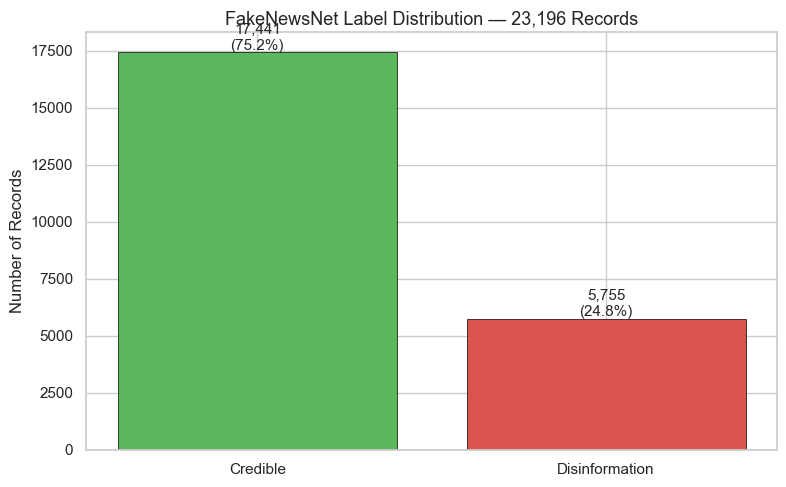

Imbalanced: 24.8% disinformation — HyDMIS Stage 1 needs class weighting


In [3]:
dis = (df['label']==1).sum(); cred = (df['label']==0).sum()

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(['Credible','Disinformation'], [cred, dis],
              color=['#5cb85c','#d9534f'], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, [cred, dis]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
            f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=11)
ax.set_title('FakeNewsNet Label Distribution — 23,196 Records', fontsize=13)
ax.set_ylabel('Number of Records')
plt.tight_layout()
plt.savefig('../figures/eda/fakenewsnet_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Imbalanced: 24.8% disinformation — HyDMIS Stage 1 needs class weighting')

## 2. Source Distribution — GossipCop Dominates

GossipCop (95.4%) overwhelms PolitiFact (4.6%). Separate analysis required per platform.

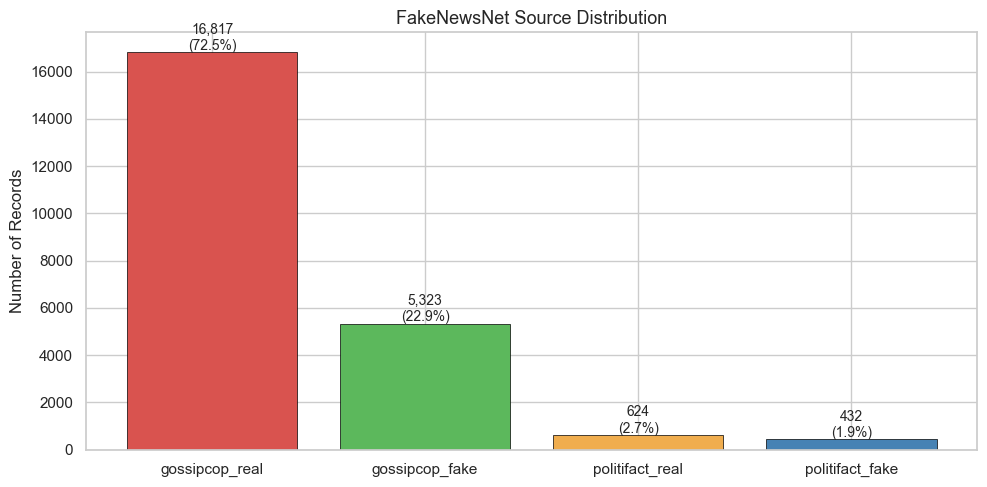

In [4]:
src_counts = df['source'].value_counts()
src_colors = ['#d9534f','#5cb85c','#f0ad4e','steelblue']

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(src_counts.index, src_counts.values, color=src_colors,
              edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, src_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
            f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=10)
ax.set_title('FakeNewsNet Source Distribution', fontsize=13)
ax.set_ylabel('Number of Records')
plt.tight_layout()
plt.savefig('../figures/eda/fakenewsnet_source_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Disinformation Rate by Source

All sources are 100% fake or 100% real by design — labels come from source filenames.

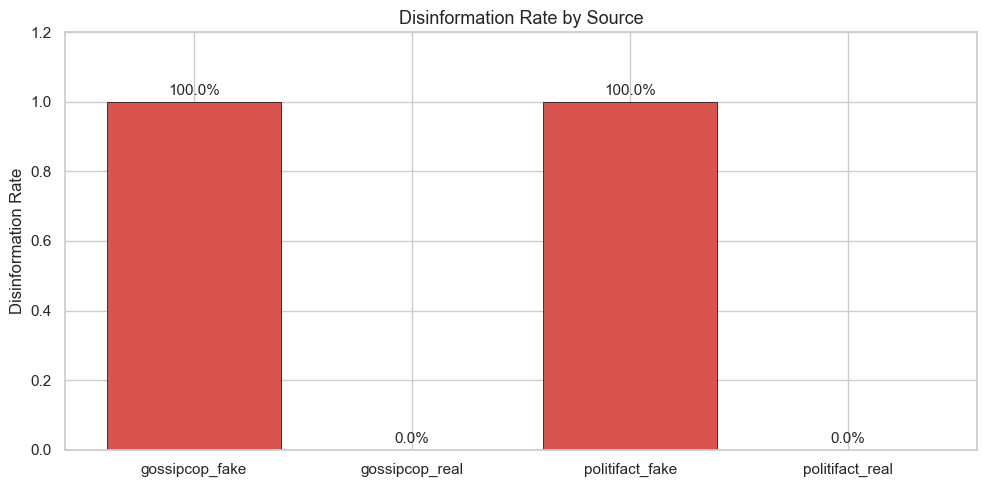

Labels are source-derived: _fake=100% disinformation, _real=0%


In [5]:
src_dis = df.groupby('source')['label'].mean()

fig, ax = plt.subplots(figsize=(10,5))
colors = ['#d9534f' if v > 0.5 else '#5cb85c' for v in src_dis.values]
bars = ax.bar(src_dis.index, src_dis.values, color=colors,
              edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, src_dis.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{val:.1%}', ha='center', fontsize=11)
ax.set_title('Disinformation Rate by Source', fontsize=13)
ax.set_ylabel('Disinformation Rate')
ax.set_ylim(0, 1.2)
plt.tight_layout()
plt.savefig('../figures/eda/fakenewsnet_dis_rate_by_source.png', dpi=150, bbox_inches='tight')
plt.show()
print('Labels are source-derived: _fake=100% disinformation, _real=0%')

## 4. Platform Comparison — PolitiFact vs GossipCop

PolitiFact: political fact-checking. GossipCop: celebrity news. Completely different domains.

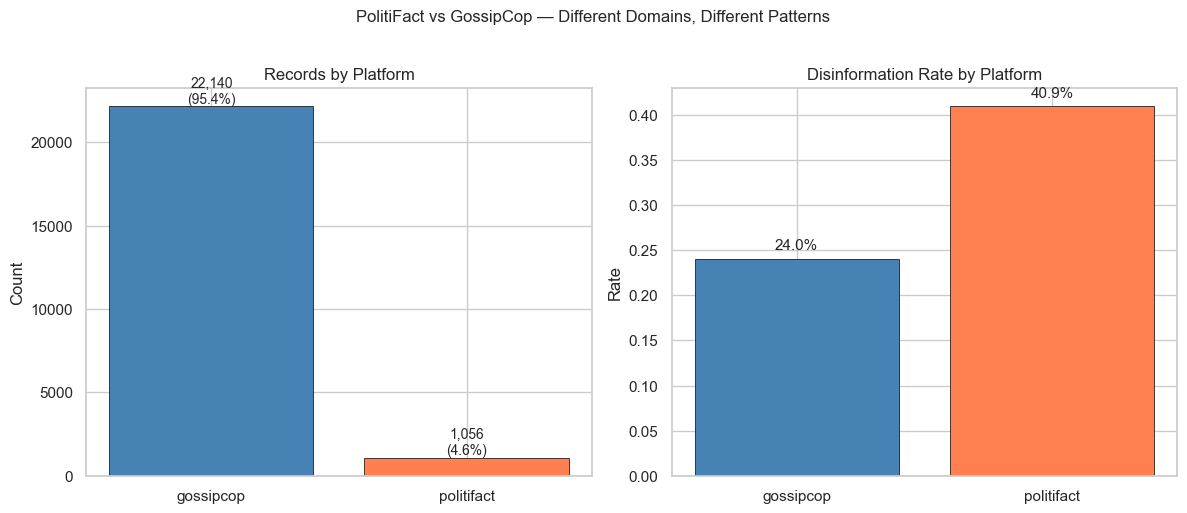

In [6]:
plat_stats = df.groupby('platform').agg(
    count=('label','count'),
    dis_rate=('label','mean'),
    mean_title_len=('title_len','mean')
).reset_index()

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5))
ax1.bar(plat_stats['platform'], plat_stats['count'],
        color=['steelblue','coral'], edgecolor='black', linewidth=0.5)
for i, row in plat_stats.iterrows():
    ax1.text(i, row['count']+200, f'{row["count"]:,}\n({row["count"]/len(df):.1%})',
             ha='center', fontsize=10)
ax1.set_title('Records by Platform', fontsize=12); ax1.set_ylabel('Count')

ax2.bar(plat_stats['platform'], plat_stats['dis_rate'],
        color=['steelblue','coral'], edgecolor='black', linewidth=0.5)
for i, row in plat_stats.iterrows():
    ax2.text(i, row['dis_rate']+0.01, f'{row["dis_rate"]:.1%}', ha='center', fontsize=11)
ax2.set_title('Disinformation Rate by Platform', fontsize=12); ax2.set_ylabel('Rate')

plt.suptitle('PolitiFact vs GossipCop — Different Domains, Different Patterns', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/fakenewsnet_platform_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Title Length by Label

Near-zero correlation (r=0.013) — title length alone is not a disinformation signal.

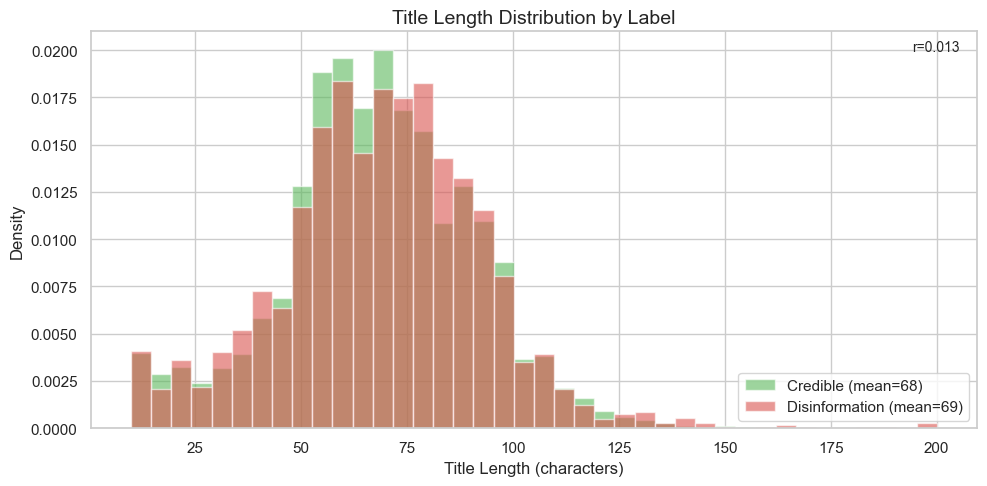

r=0.013 — title length not a useful feature for disinformation detection


In [7]:
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(df[df['label']==0]['title_len'].clip(upper=200), bins=40, alpha=0.6,
        color='#5cb85c', label=f'Credible (mean={df[df["label"]==0]["title_len"].mean():.0f})', density=True)
ax.hist(df[df['label']==1]['title_len'].clip(upper=200), bins=40, alpha=0.6,
        color='#d9534f', label=f'Disinformation (mean={df[df["label"]==1]["title_len"].mean():.0f})', density=True)
corr = df['title_len'].corr(df['label'])
ax.text(0.98, 0.95, f'r={corr:.3f}', transform=ax.transAxes, fontsize=10, ha='right')
ax.set_title('Title Length Distribution by Label', fontsize=14)
ax.set_xlabel('Title Length (characters)')
ax.set_ylabel('Density'); ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/fakenewsnet_title_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('r=0.013 — title length not a useful feature for disinformation detection')

## 6. Title Length by Source

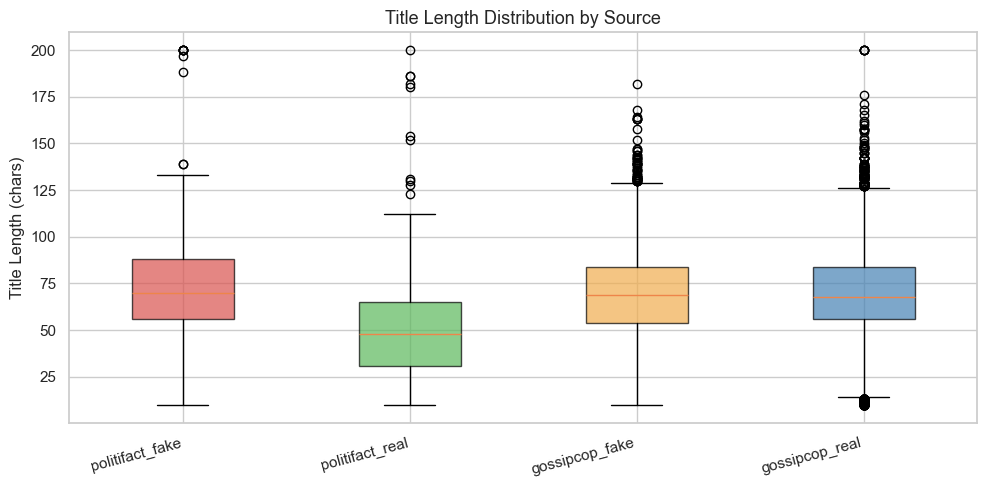

PolitiFact real titles shortest (mean=51) — concise factual reporting


In [8]:
fig, ax = plt.subplots(figsize=(10,5))
src_order = ['politifact_fake','politifact_real','gossipcop_fake','gossipcop_real']
data_to_plot = [df[df['source']==s]['title_len'].clip(upper=200) for s in src_order]
bp = ax.boxplot(data_to_plot, labels=src_order, patch_artist=True)
colors = ['#d9534f','#5cb85c','#f0ad4e','steelblue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title('Title Length Distribution by Source', fontsize=13)
ax.set_ylabel('Title Length (chars)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../figures/eda/fakenewsnet_title_length_by_source.png', dpi=150, bbox_inches='tight')
plt.show()
print('PolitiFact real titles shortest (mean=51) — concise factual reporting')

## 7. PolitiFact Keywords — Political Disinformation

Disinformation: trump, breaking, obama, clinton. Credible: transcript, debate, remarks, senate.

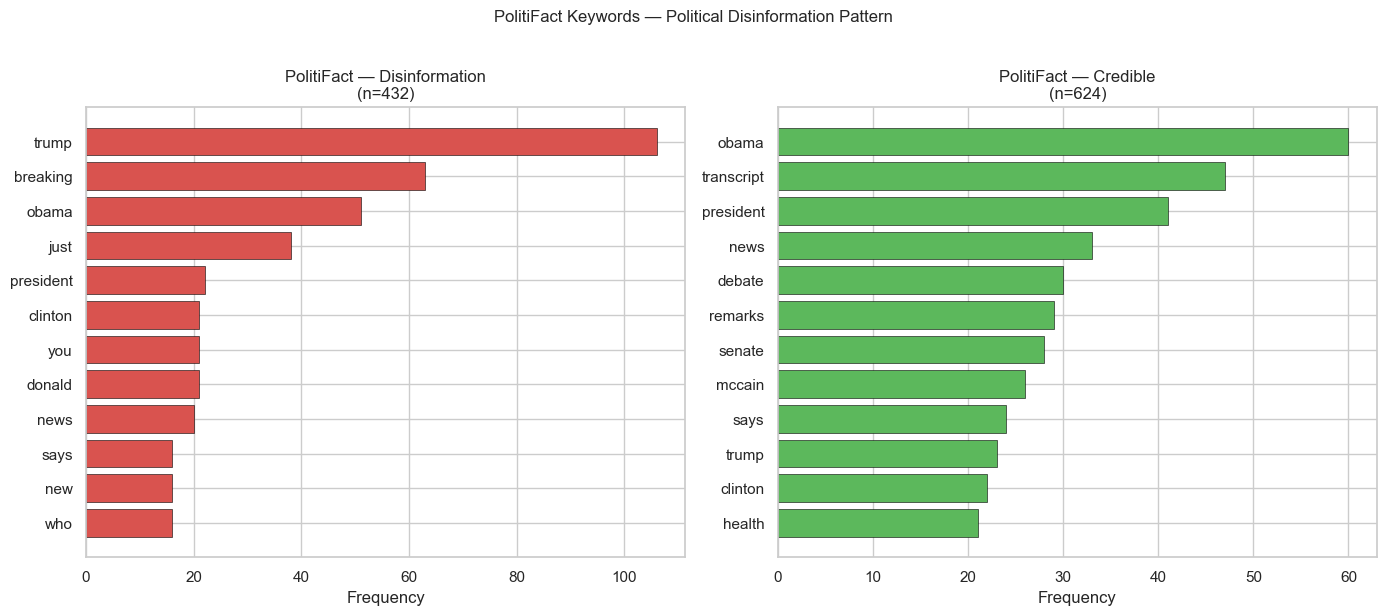

Disinformation: trump/breaking/obama/clinton | Credible: transcript/debate/remarks/senate


In [9]:
pf = df[df['platform']=='politifact']
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(14,6))

for ax, label, name, color in [(ax1,1,'Disinformation','#d9534f'),(ax2,0,'Credible','#5cb85c')]:
    subset = pf[pf['label']==label]
    words = []
    for t in subset['title'].astype(str):
        words.extend([w.lower() for w in re.findall(r'\b[a-zA-Z]{3,}\b', t)
                     if w.lower() not in STOPWORDS])
    top = Counter(words).most_common(12)
    kws, counts = zip(*top)
    ax.barh(list(kws)[::-1], list(counts)[::-1], color=color, edgecolor='black', linewidth=0.4)
    ax.set_title(f'PolitiFact — {name}\n(n={len(subset):,})', fontsize=12)
    ax.set_xlabel('Frequency')

plt.suptitle('PolitiFact Keywords — Political Disinformation Pattern', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/fakenewsnet_politifact_keywords.png', dpi=150, bbox_inches='tight')
plt.show()
print('Disinformation: trump/breaking/obama/clinton | Credible: transcript/debate/remarks/senate')

## 8. GossipCop Keywords — Celebrity Disinformation

Disinformation: jennifer, kardashian, brad, pitt. Credible: awards, season, wedding, star.

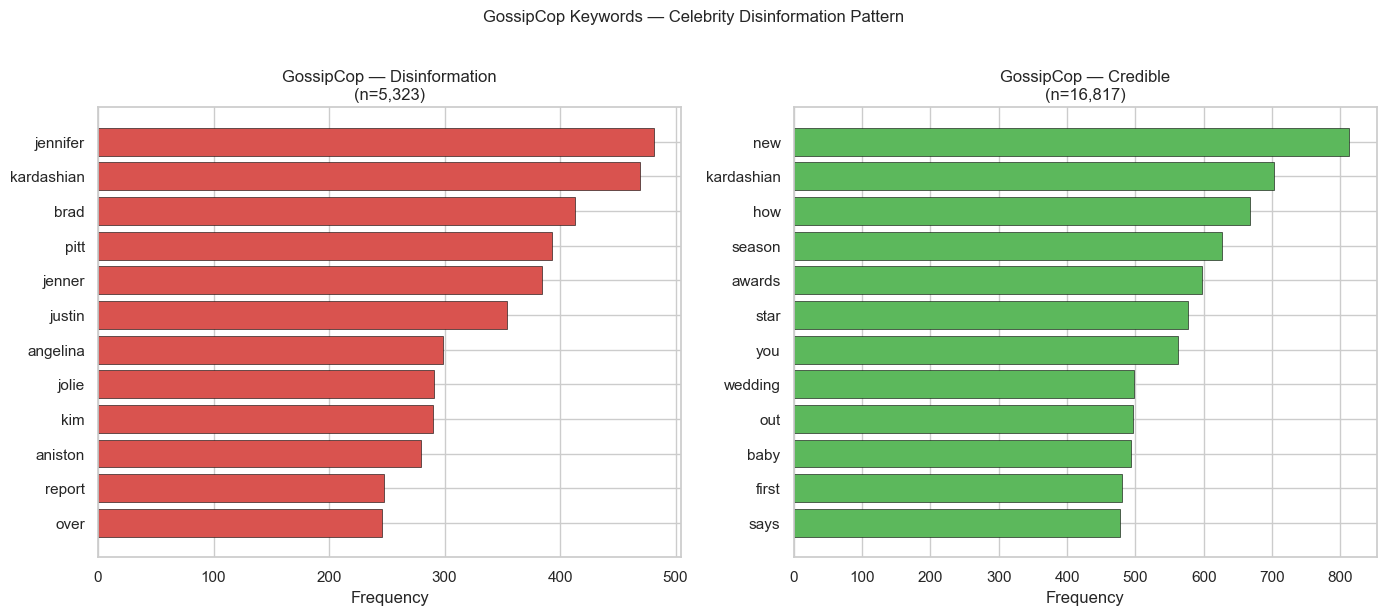

Disinformation: jennifer/kardashian/brad/pitt | Credible: awards/season/wedding/star


In [10]:
gc = df[df['platform']=='gossipcop']
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(14,6))

for ax, label, name, color in [(ax1,1,'Disinformation','#d9534f'),(ax2,0,'Credible','#5cb85c')]:
    subset = gc[gc['label']==label]
    words = []
    for t in subset['title'].astype(str):
        words.extend([w.lower() for w in re.findall(r'\b[a-zA-Z]{3,}\b', t)
                     if w.lower() not in STOPWORDS])
    top = Counter(words).most_common(12)
    kws, counts = zip(*top)
    ax.barh(list(kws)[::-1], list(counts)[::-1], color=color, edgecolor='black', linewidth=0.4)
    ax.set_title(f'GossipCop — {name}\n(n={len(subset):,})', fontsize=12)
    ax.set_xlabel('Frequency')

plt.suptitle('GossipCop Keywords — Celebrity Disinformation Pattern', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/fakenewsnet_gossipcop_keywords.png', dpi=150, bbox_inches='tight')
plt.show()
print('Disinformation: jennifer/kardashian/brad/pitt | Credible: awards/season/wedding/star')

## 9. Missing Values

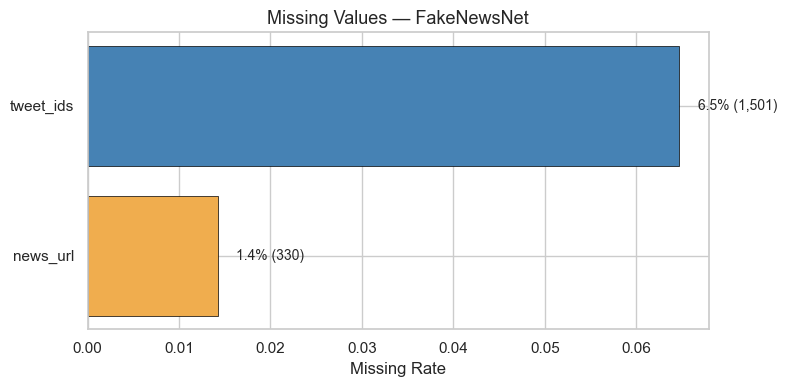

tweet_ids 6.5% missing — social graph not used in HyDMIS anyway


In [11]:
missing_cols = ['news_url','tweet_ids']
missing_vals = [df[c].isna().sum() for c in missing_cols]
missing_pcts = [df[c].isna().mean() for c in missing_cols]

fig, ax = plt.subplots(figsize=(8,4))
bars = ax.barh(missing_cols, missing_pcts,
               color=['#f0ad4e','steelblue'], edgecolor='black', linewidth=0.5)
for bar, val, n in zip(bars, missing_pcts, missing_vals):
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
            f'{val:.1%} ({n:,})', va='center', fontsize=10)
ax.set_title('Missing Values — FakeNewsNet', fontsize=13)
ax.set_xlabel('Missing Rate')
plt.tight_layout()
plt.savefig('../figures/eda/fakenewsnet_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('tweet_ids 6.5% missing — social graph not used in HyDMIS anyway')

## 10. Word Count Distribution by Label

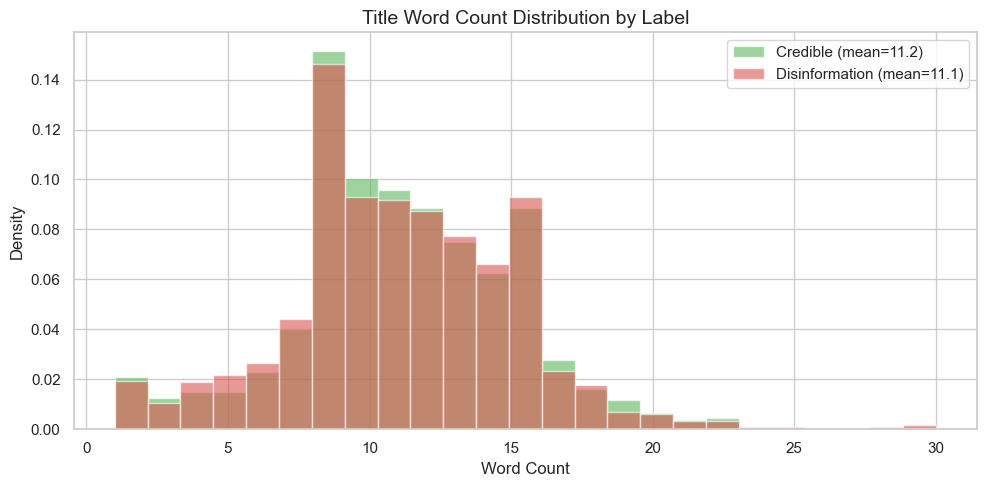

In [12]:
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(df[df['label']==0]['word_count'].clip(upper=30), bins=25, alpha=0.6,
        color='#5cb85c', label=f'Credible (mean={df[df["label"]==0]["word_count"].mean():.1f})', density=True)
ax.hist(df[df['label']==1]['word_count'].clip(upper=30), bins=25, alpha=0.6,
        color='#d9534f', label=f'Disinformation (mean={df[df["label"]==1]["word_count"].mean():.1f})', density=True)
ax.set_title('Title Word Count Distribution by Label', fontsize=14)
ax.set_xlabel('Word Count')
ax.set_ylabel('Density'); ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/fakenewsnet_word_count.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. URL and Tweet Availability as Disinformation Signal

No URL → 78.8% disinformation rate vs Has URL → 24.0% — 3x difference. Articles without source URLs are overwhelmingly fake. No tweets → 15.2% disinformation — articles without social engagement are more credible.

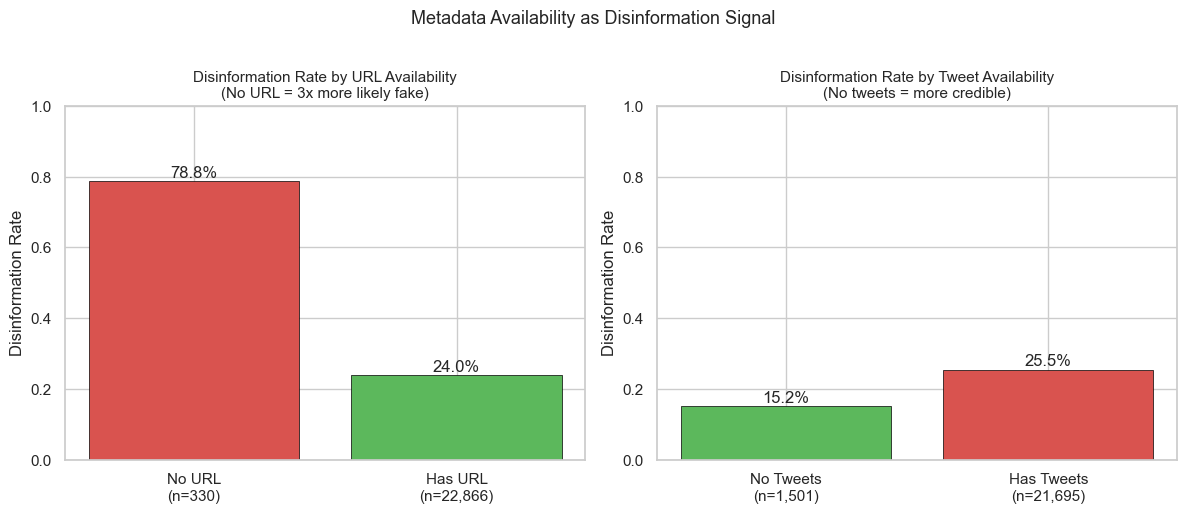

No URL: 78.8% dis rate — missing source URL is strong fake signal
No tweets: 15.2% dis rate — low social engagement correlates with credibility


In [13]:
df['has_url'] = df['news_url'].notna()
df['has_tweets'] = df['tweet_ids'].notna()

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5))

# URL availability
url_stats = df.groupby('has_url')['label'].agg(['mean','count']).reset_index()
url_labels = ['No URL\n(n={:,})'.format(url_stats[~url_stats['has_url']]['count'].values[0]),
              'Has URL\n(n={:,})'.format(url_stats[url_stats['has_url']]['count'].values[0])]
url_rates = [url_stats[~url_stats['has_url']]['mean'].values[0],
             url_stats[url_stats['has_url']]['mean'].values[0]]
bars1 = ax1.bar(url_labels, url_rates, color=['#d9534f','#5cb85c'],
                edgecolor='black', linewidth=0.5)
for bar, val in zip(bars1, url_rates):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.1%}', ha='center', fontsize=12)
ax1.set_title('Disinformation Rate by URL Availability\n(No URL = 3x more likely fake)', fontsize=11)
ax1.set_ylabel('Disinformation Rate'); ax1.set_ylim(0,1.0)

# Tweet availability
tweet_stats = df.groupby('has_tweets')['label'].agg(['mean','count']).reset_index()
tweet_labels = ['No Tweets\n(n={:,})'.format(tweet_stats[~tweet_stats['has_tweets']]['count'].values[0]),
                'Has Tweets\n(n={:,})'.format(tweet_stats[tweet_stats['has_tweets']]['count'].values[0])]
tweet_rates = [tweet_stats[~tweet_stats['has_tweets']]['mean'].values[0],
               tweet_stats[tweet_stats['has_tweets']]['mean'].values[0]]
bars2 = ax2.bar(tweet_labels, tweet_rates, color=['#5cb85c','#d9534f'],
                edgecolor='black', linewidth=0.5)
for bar, val in zip(bars2, tweet_rates):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.1%}', ha='center', fontsize=12)
ax2.set_title('Disinformation Rate by Tweet Availability\n(No tweets = more credible)', fontsize=11)
ax2.set_ylabel('Disinformation Rate'); ax2.set_ylim(0,1.0)

plt.suptitle('Metadata Availability as Disinformation Signal', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/fakenewsnet_metadata_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print('No URL: 78.8% dis rate — missing source URL is strong fake signal')
print('No tweets: 15.2% dis rate — low social engagement correlates with credibility')

## 12. Key Observations

**Imbalanced dataset:** 24.8% disinformation vs 75.2% credible. HyDMIS Stage 1 needs class weighting.

**Platform imbalance:** GossipCop (95.4%) overwhelms PolitiFact (4.6%). Combined analysis misleading — platform-split required.

**Two completely different disinformation patterns:**
- PolitiFact: trump, breaking, obama, clinton — political misinformation
- GossipCop: jennifer, kardashian, brad, pitt — celebrity gossip fabrication

**Title length not useful:** r=0.013 — length alone cannot distinguish disinformation.

**Content-only by design:** tweet_ids available but social graph excluded — mirrors low-resource multilingual settings where social graphs unavailable.